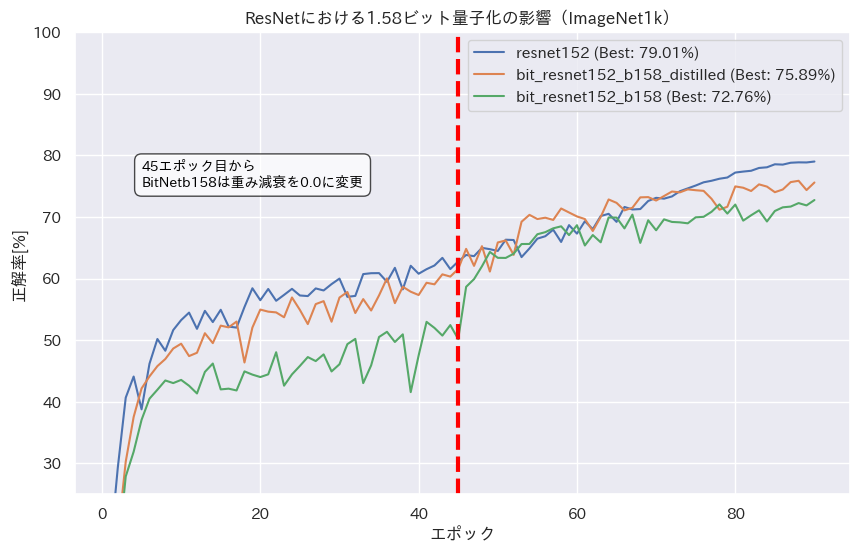

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import seaborn as sns
import re


class ModelAnalyzer:
    def __init__(self, pretrain_dir, kd_dirs):
        self.pretrain_dirs = [
            f"{pretrain_dir}/{d}/"
            for d in os.listdir(pretrain_dir)
            if os.path.isdir(f"{pretrain_dir}/{d}")
        ] + [
            f"{kd_dirs}/0000/{d}/"
            for d in os.listdir(f"{kd_dirs}/0000/")
            if os.path.isdir(f"{kd_dirs}/0000/{d}")
        ]

    def extract_scalar_arrays(self, scalar_events):
        return (
            np.array([event.wall_time for event in scalar_events]),
            np.array([event.step for event in scalar_events]),
            np.array([event.value for event in scalar_events]),
        )

    def plot_model_accuracy(self):
        plt.figure(figsize=(10, 6))

        # 各モデルのログデータを読み込み、最高精度を取得しリストに保存
        model_accuracy = []
        for pretrain_dir in self.pretrain_dirs:
            model_name = os.path.basename(os.path.normpath(pretrain_dir))
            accumulator = EventAccumulator(pretrain_dir)
            accumulator.Reload()
            wall_times, steps, values = self.extract_scalar_arrays(
                accumulator.Scalars("test_top1")
            )
            max_accuracy = max(values)  # 最高精度を取得
            model_accuracy.append((model_name, max_accuracy))

        # 精度の降順にソート
        model_accuracy.sort(key=lambda x: x[1], reverse=True)

        # ソートされた順番に従ってプロット
        for model_name, _ in model_accuracy:
            _model_name = model_name
            if '1_resnet152' in model_name:
                continue
            elif '0_bit_resnet152' in model_name:
                _model_name = 'bit_resnet152_b158_distilled'
            try:
                accumulator = EventAccumulator(os.path.join("runs/pre-train", model_name))
                accumulator.Reload()
            except:
                accumulator = EventAccumulator(os.path.join("runs/bit_kd_2/0000", model_name))
                accumulator.Reload()
            wall_times, steps, values = self.extract_scalar_arrays(
                accumulator.Scalars("test_top1")
            )
            plt.plot(steps, values, label=f"{_model_name} (Best: {max(values):.2f}%)")

        # タイトルや軸ラベルを設定
        plt.title("ResNetにおける1.58ビット量子化の影響（ImageNet1k）")
        plt.xlabel("エポック")
        plt.ylabel("正解率[%]")
        plt.ylim(25, 100)

        # 凡例を表示
        plt.legend()

        # グリッドを表示
        plt.grid(True)

        plt.axvline(x=45, color="red", linestyle="--", linewidth=3)
        bbox_props = dict(
            boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.7
        )
        plt.text(
            5,
            75,
            "45エポック目から\nBitNetb158は重み減衰を0.0に変更",
            fontsize=10,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.5", fc="white", ec="black", lw=1, alpha=0.7
            ),
        )

        # グラフを保存して表示
        plt.savefig("pre-train.svg")
        plt.show()
        return model_accuracy

    def extract_number(self, model_name):
        match = re.search(r"\d+", model_name)
        return int(match.group()) if match else None

analyzer = ModelAnalyzer("runs/pre-train", "runs/bit_kd_2")
model_accuracy = analyzer.plot_model_accuracy()